#Tutorial: Construindo Redes Neurais com TensorFlow para Reconhecimento de Dígitos (MNIST)

##Introdução

As Redes Neurais Artificiais (RNAs) são modelos computacionais inspirados no funcionamento do cérebro humano, que têm sido amplamente utilizados em diversas áreas da ciência e da tecnologia, incluindo reconhecimento de padrões, processamento de linguagem natural, visão computacional e muito mais. Uma das bibliotecas mais populares para construir e treinar RNAs é o TensorFlow.

O TensorFlow é uma biblioteca de código aberto desenvolvida pelo Google, que oferece uma estrutura flexível e eficiente para construir, treinar e implantar modelos de machine learning e deep learning. Ele é especialmente conhecida por sua flexibilidade e escalabilidade, sendo amplamente utilizado tanto em projetos de pesquisa quanto em aplicações industriais.

Neste tutorial, vamos explorar passo a passo como construir Redes Neurais usando TensorFlow para realizar o reconhecimento de dígitos manuscritos. Para isso, utilizaremos o conjunto de dados MNIST, que é um conjunto de imagens de dígitos escritos à mão, amplamente utilizado como benchmark na comunidade de aprendizado de máquina.

## Instalação de bibliotecas:

In [1]:
!pip install numpy matplotlib tensorflow scikit-learn

## Importação das bibliotecas:

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## Carregamento e visualização dos dados:

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


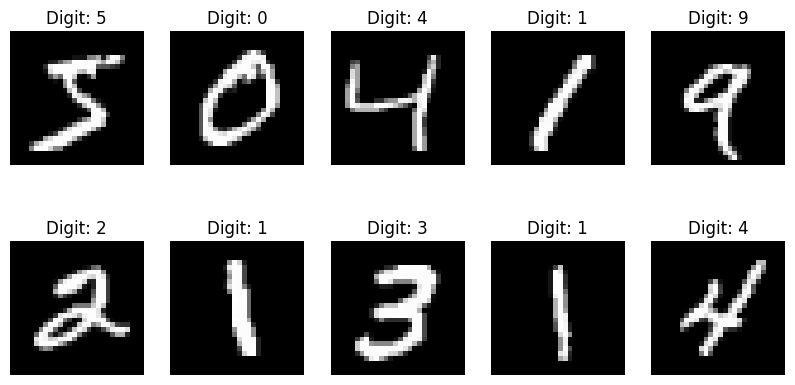

In [3]:
# Carregamento dos dados
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Visualização das primeiras 10 imagens do conjunto de treinamento
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f'Digit: {y_train[i]}')
    plt.axis('off')
plt.show()


## Pré-processamento dos dados:
Neste etapa será realizada a normalização dos dados e redimensionamento para o formato adequado.

In [4]:
# Redimensionamento e normalização dos dados
X_train = X_train.reshape(-1, 28 * 28) / 255.0
X_test = X_test.reshape(-1, 28 * 28) / 255.0

# One-hot encoding das variáveis alvo
y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)


## Divisão dos dados:
O Dataset MNIST fornece dados de treinamento e teste separados. Além desses será criado o conjunto de validação, que permite avaliar a rede com dados externos ao treinamento, em tempo de execução.

In [5]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=42)

## Single Layer Network

In [22]:
# Definição do modelo
model_single_layer = Sequential([
    Dense(16, activation='relu', input_shape=(784,)),
    Dense(10, activation='softmax')
])

# Exibindo um resumo da arquitetura da rede
model_single_layer.summary()

# Compilação do modelo
model_single_layer.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Treinamento do modelo
history_single_layer = model_single_layer.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_val, y_val))


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                      │ (None, 16)                  │          12,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 10)                  │             170 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 12,730 (49.73 KB)

 Trainable params: 12,730 (49.73 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7672 - loss: 0.7989 - val_accuracy: 0.9188 - val_loss: 0.2825
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9226 - loss: 0.2676 - val_accuracy: 0.9282 - val_loss: 0.2477
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9322 - loss: 0.2332 - val_accuracy: 0.9347 - val_loss: 0.2224
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9387 - loss: 0.2160 - val_accuracy: 0.9380 - val_loss: 0.2118
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9441 - loss: 0.1964 - val_accuracy: 0.9407 - val_loss: 0.1998
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9434 - loss: 0.1909 - val_accuracy: 0.9423 - val_loss: 0.1990
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9486 - loss: 0.1831 - val_accuracy: 0.9425 - val_loss: 0.1930
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9476 - loss: 0.1785 - 

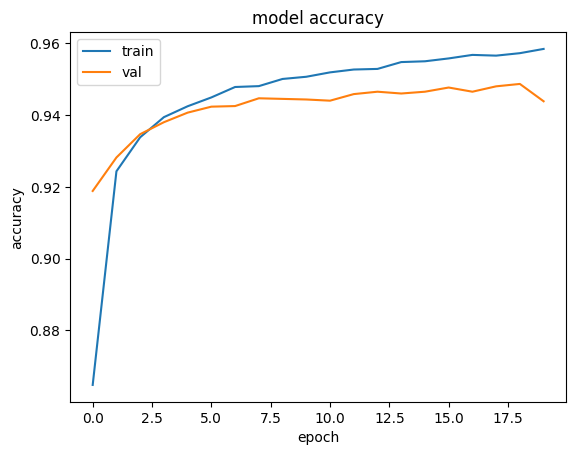

In [23]:
plt.plot(history_single_layer.history['accuracy'])
plt.plot(history_single_layer.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [24]:
# Avaliação do modelo de camada única
_, accuracy_single_layer = model_single_layer.evaluate(X_test, y_test)
print("Accuracy of Single Layer Neural Network:", accuracy_single_layer)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9416 - loss: 0.2077
Accuracy of Single Layer Neural Network: 0.9470000267028809


## Multi Layer Network (MLP)

In [29]:
# Definição do modelo
model_mlp = Sequential([
    Dense(256, activation='relu', input_shape=(784,)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

# Exibindo um resumo da arquitetura da rede
model_mlp.summary()

# Compilação do modelo
model_mlp.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Treinamento do modelo
history_mlp = model_mlp.fit(X_train, y_train, epochs=10, batch_size=128, validation_data=(X_val, y_val))


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                     │ (None, 256)                 │         200,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_16 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_17 (Dense)                     │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8462 - loss: 0.5309 - val_accuracy: 0.9632 - val_loss: 0.1247
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9672 - loss: 0.1125 - val_accuracy: 0.9562 - val_loss: 0.1383
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9786 - loss: 0.0689 - val_accuracy: 0.9725 - val_loss: 0.0892
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9843 - loss: 0.0486 - val_accuracy: 0.9783 - val_loss: 0.0736
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9894 - loss: 0.0351 - val_accuracy: 0.9783 - val_loss: 0.0749
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9918 - loss: 0.0264 - val_accuracy: 0.9772 - val_loss: 0.0747
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.9931 - loss: 0.0212 - val_accuracy: 0.9820 - val_loss: 0.0652
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.9947 - loss: 0.0162 - val_accuracy:

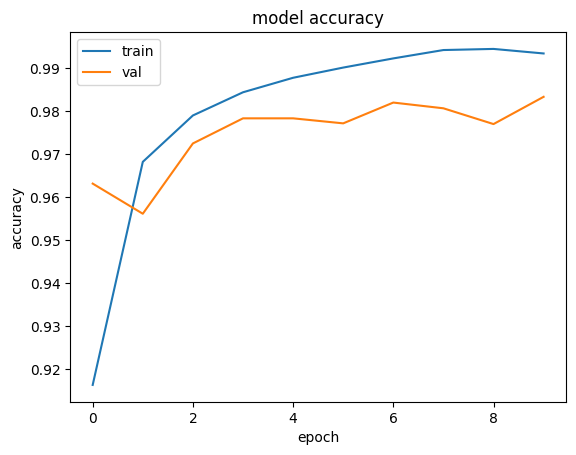

In [30]:
plt.plot(history_mlp.history['accuracy'])
plt.plot(history_mlp.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [31]:
model_mlp.summary()

# Avaliação do modelo MLP
_, accuracy_mlp = model_mlp.evaluate(X_test, y_test)
print("Accuracy of MLP:", accuracy_mlp)

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                     │ (None, 256)                 │         200,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_16 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_17 (Dense)                     │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 728,288 (2.78 MB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 485,526 (1.85 MB)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9775 - loss: 0.0950
Accuracy of MLP: 0.9804999828338623


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


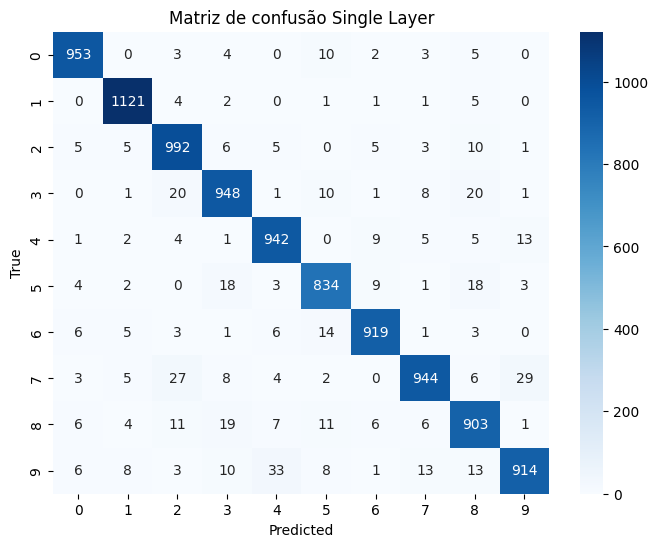

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


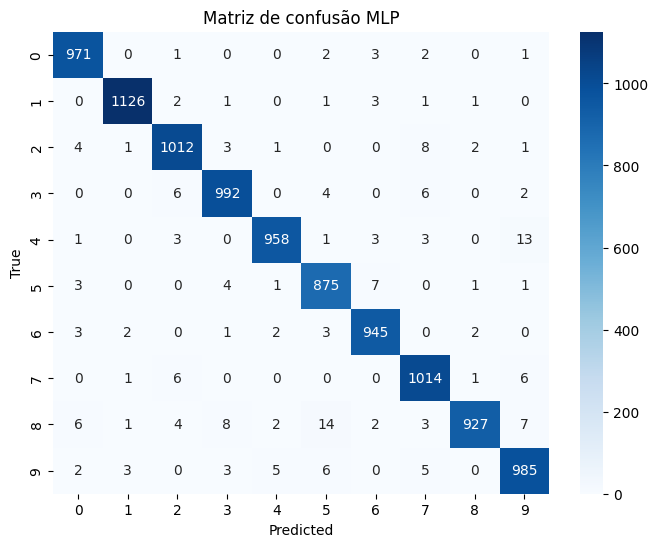

In [32]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Função para plotar matriz de confusão
def plot_confusion_matrix(model, X_test, y_test, title='Confusion Matrix'):
    y_pred = np.argmax(model.predict(X_test), axis=1)
    cm = confusion_matrix(np.argmax(y_test, axis=1), y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(title)
    plt.show()

# Matriz de confusão para o modelo de camada única
plot_confusion_matrix(model_single_layer, X_test, y_test, "Matriz de confusão Single Layer")

# Matriz de confusão para o modelo MLP
plot_confusion_matrix(model_mlp, X_test, y_test, "Matriz de confusão MLP")


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


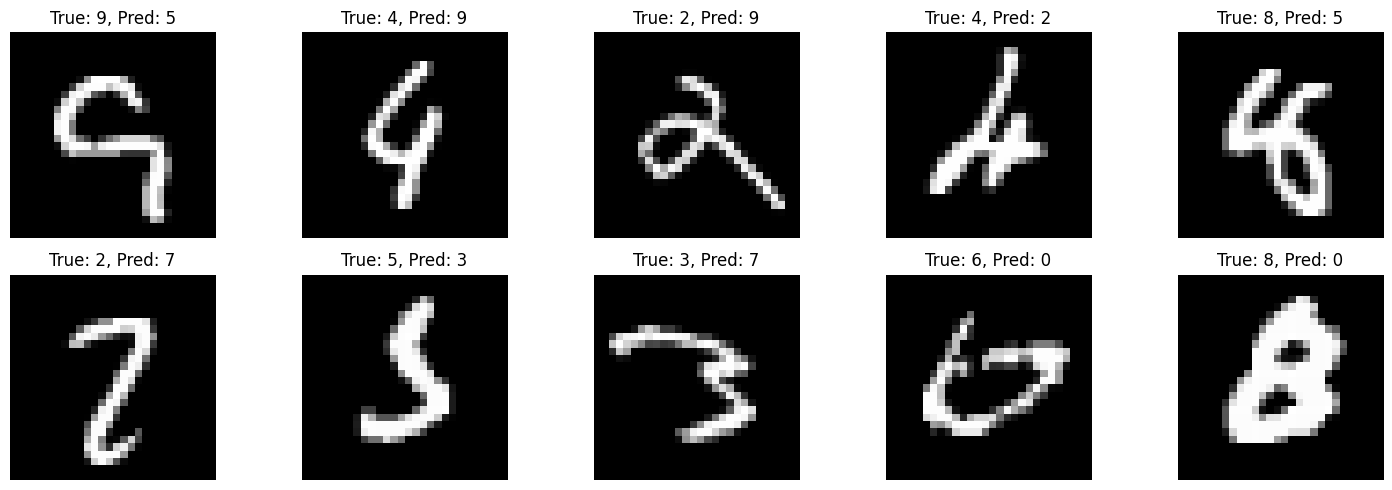

In [33]:
# prompt: crie um código em selecione os 10 primeros casos de erro na classifcação do conjunto de tstes do modelo model_mlp. Apresente os resultados em uma figura

y_pred_mlp = np.argmax(model_mlp.predict(X_test), axis=1)
y_true_mlp = np.argmax(y_test, axis=1)

incorrect_indices_mlp = np.where(y_pred_mlp != y_true_mlp)[0]

# Selecionar os 10 primeiros casos de erro
top_10_incorrect_indices_mlp = incorrect_indices_mlp[:10]

plt.figure(figsize=(15, 5))
for i, index in enumerate(top_10_incorrect_indices_mlp):
  plt.subplot(2, 5, i + 1)
  plt.imshow(X_test[index].reshape(28, 28), cmap='gray')
  plt.title(f'True: {y_true_mlp[index]}, Pred: {y_pred_mlp[index]}')
  plt.axis('off')

plt.tight_layout()
plt.show()

## HiperParâmetros

Os hiperparâmetros em Redes Neurais Artificiais são parâmetros cujos valores não são aprendidos durante o treinamento do modelo, mas devem ser definidos antes do início do treinamento. Eles determinam a arquitetura e o comportamento do modelo de RNA e têm um impacto significativo no desempenho final do modelo. Alguns exemplos comuns de hiperparâmetros incluem o número de camadas e unidades ocultas, as funções de ativação, a taxa de aprendizado e o tamanho do lote.

## Importância dos Hiperparâmetros
Os hiperparâmetros desempenham um papel crucial no desenvolvimento de Redes Neurais Artificiais e têm um impacto direto na capacidade do modelo de aprender e generalizar a partir dos dados. Aqui estão algumas razões pelas quais os hiperparâmetros são importantes:

**Arquitetura do Modelo:** Os hiperparâmetros, como o número de camadas e unidades ocultas, determinam a arquitetura geral do modelo. Uma arquitetura adequada pode facilitar a representação e a aprendizagem de padrões complexos nos dados.

**Generalização:** A escolha dos hiperparâmetros afeta diretamente a capacidade do modelo de generalizar para dados não vistos. Uma configuração inadequada dos hiperparâmetros pode levar a overfitting (sobreajuste) ou underfitting (subajuste) do modelo.

**Desempenho do Modelo: **Os hiperparâmetros têm um impacto direto no desempenho final do modelo. Uma seleção cuidadosa dos hiperparâmetros pode levar a modelos mais precisos e eficientes.

**Interpretabilidade:** Alguns hiperparâmetros, como as funções de ativação e as taxas de regularização, podem influenciar a interpretabilidade do modelo e a facilidade de compreensão dos resultados.

**Eficiência Computacional: **Uma escolha adequada dos hiperparâmetros pode tornar o processo de treinamento mais eficiente, reduzindo o tempo e os recursos computacionais necessários para treinar o modelo.

## Otimização de Hiperparâmetros
Dada a importância dos hiperparâmetros, a otimização desses parâmetros é uma etapa crucial no desenvolvimento de Redes Neurais Artificiais. Existem várias técnicas para otimizar os hiperparâmetros, incluindo pesquisa em grade, pesquisa aleatória, otimização bayesiana e algoritmos de otimização mais avançados, como algoritmos genéticos e otimização por enxame de partículas.

A escolha dos hiperparâmetros certos é uma parte essencial do processo de construção de modelos de RNA eficazes e bem-sucedidos. Experimentar diferentes combinações de hiperparâmetros e entender seu impacto no desempenho do modelo é fundamental para obter os melhores resultados em tarefas de aprendizado de máquina e deep learning.

## Arquitetura

In [34]:
# Testando diferentes arquiteturas de rede neural com número de camadas e unidades ocultas variáveis

architectures = [
    (8,),
    (16,),
    (32,),
    (64,),
    (64, 32),
    (128, 64),
    (512, 256, 128)
]

results = []

for architecture in architectures:
    model = Sequential()
    for units in architecture:
        model.add(Dense(units, activation='relu'))
    model.add(Dense(10, activation='softmax'))

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    history = model.fit(X_train, y_train, epochs=10, batch_size=128, validation_data=(X_val, y_val), verbose=0)

    _, accuracy = model.evaluate(X_test, y_test)
    results.append((architecture, accuracy))
    print(f"Architecture {architecture} - Test Accuracy: {accuracy}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9104 - loss: 0.3175
Architecture (8,) - Test Accuracy: 0.9208999872207642
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9340 - loss: 0.2208
Architecture (16,) - Test Accuracy: 0.9433000087738037
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9558 - loss: 0.1602
Architecture (32,) - Test Accuracy: 0.9610999822616577
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9669 - loss: 0.1084
Architecture (64,) - Test Accuracy: 0.9704999923706055
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9710 - loss: 0.0988
Architecture (64, 32) - Test Accuracy: 0.9740999937057495
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9735 - loss: 0.0949
Architecture (128, 64) - Test Accuracy: 0.9769999980926514
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9764 - loss: 0.1079
Architecture (512, 256, 128) - Test Accuracy: 0.9796000123023987


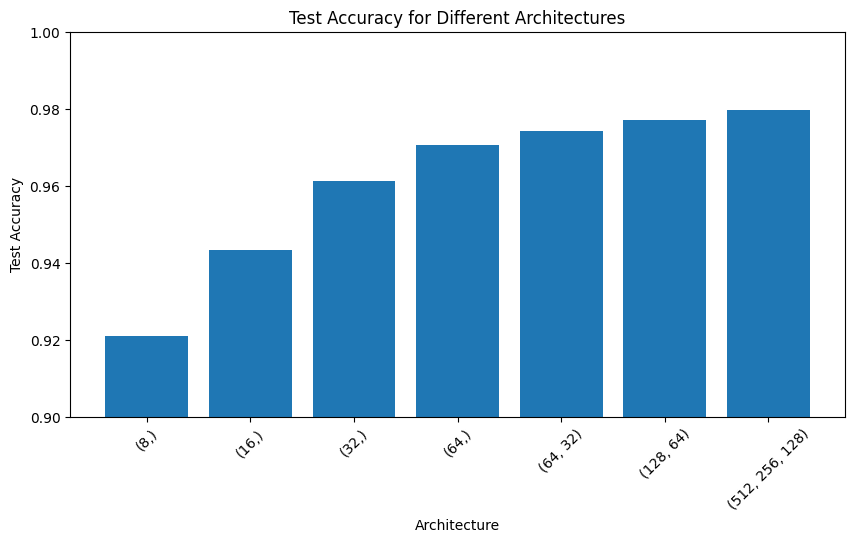

In [35]:
# Plotando os resultados
plt.figure(figsize=(10, 5))
architectures_str = [str(architecture) for architecture, _ in results]
accuracies = [accuracy for _, accuracy in results]
plt.bar(architectures_str, accuracies)
plt.title('Test Accuracy for Different Architectures')
plt.xlabel('Architecture')
plt.ylabel('Test Accuracy')
plt.ylim(0.9, 1)
plt.xticks(rotation=45)
plt.show()

## Funções de Ativação

313/313 [==============================] - 1s 2ms/step - loss: 0.0827 - accuracy: 0.9764
Activation Function: relu - Test Accuracy: 0.9764000177383423
313/313 [==============================] - 2s 5ms/step - loss: 0.0716 - accuracy: 0.9775
Activation Function: tanh - Test Accuracy: 0.9775000214576721
313/313 [==============================] - 1s 2ms/step - loss: 0.0886 - accuracy: 0.9719
Activation Function: sigmoid - Test Accuracy: 0.9718999862670898


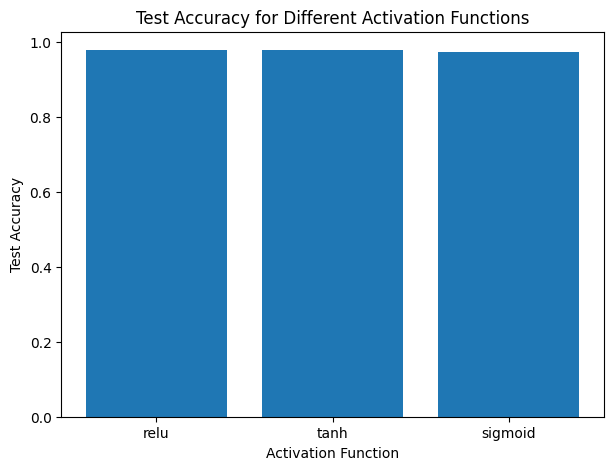

In [ ]:
# Testando diferentes funções de ativação

activation_functions = ['relu', 'tanh', 'sigmoid']

results_activation = []

for activation in activation_functions:
    model = Sequential([
        Dense(128, activation=activation, input_shape=(784,)),
        Dense(64, activation=activation),
        Dense(10, activation='softmax')
    ])

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    history = model.fit(X_train, y_train, epochs=10, batch_size=128, validation_data=(X_val, y_val), verbose=0)

    _, accuracy = model.evaluate(X_test, y_test)
    results_activation.append((activation, accuracy))
    print(f"Activation Function: {activation} - Test Accuracy: {accuracy}")

# Plotando os resultados
plt.figure(figsize=(7, 5))
activation_str = [activation for activation, _ in results_activation]
accuracies_activation = [accuracy for _, accuracy in results_activation]
plt.bar(activation_str, accuracies_activation)
plt.title('Test Accuracy for Different Activation Functions')
plt.xlabel('Activation Function')
plt.ylabel('Test Accuracy')
plt.show()


## Learning Rate

313/313 [==============================] - 1s 2ms/step - loss: 0.0726 - accuracy: 0.9776
Learning Rate: 0.001 - Test Accuracy: 0.9775999784469604
313/313 [==============================] - 1s 3ms/step - loss: 0.0819 - accuracy: 0.9778
Learning Rate: 0.003 - Test Accuracy: 0.9778000116348267
313/313 [==============================] - 1s 2ms/step - loss: 0.1496 - accuracy: 0.9659
Learning Rate: 0.01 - Test Accuracy: 0.9659000039100647
313/313 [==============================] - 1s 2ms/step - loss: 0.2156 - accuracy: 0.9557
Learning Rate: 0.03 - Test Accuracy: 0.9556999802589417
313/313 [==============================] - 1s 2ms/step - loss: 1.6327 - accuracy: 0.3688
Learning Rate: 0.1 - Test Accuracy: 0.36880001425743103
313/313 [==============================] - 1s 3ms/step - loss: 2.3120 - accuracy: 0.1135
Learning Rate: 0.3 - Test Accuracy: 0.11349999904632568


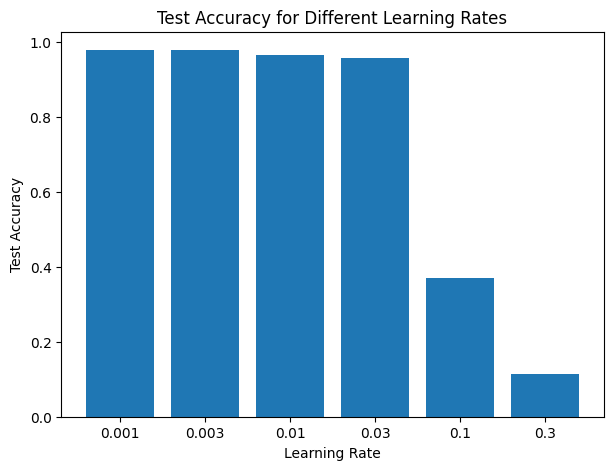

In [ ]:
# Testando diferentes taxas de aprendizado

learning_rates = [0.001, 0.003, 0.01, 0.03, 0.1, 0.3]

results_lr = []

for lr in learning_rates:
    model = Sequential([
        Dense(128, activation='relu', input_shape=(784,)),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax')
    ])

    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    history = model.fit(X_train, y_train, epochs=10, batch_size=128, validation_data=(X_val, y_val), verbose=0)

    _, accuracy = model.evaluate(X_test, y_test)
    results_lr.append((lr, accuracy))
    print(f"Learning Rate: {lr} - Test Accuracy: {accuracy}")

# Plotando os resultados
plt.figure(figsize=(7, 5))
learning_rates_str = [str(lr) for lr in learning_rates]
accuracies_lr = [accuracy for _, accuracy in results_lr]
plt.bar(learning_rates_str, accuracies_lr)
plt.title('Test Accuracy for Different Learning Rates')
plt.xlabel('Learning Rate')
plt.ylabel('Test Accuracy')
plt.show()


#Treinamento em CPU e GPU

A seguir são realizados dois treinamentos idênticos, um na CPU somente e outro na GPU. Para treinar na GPU, será necessário habilitar um ambiente que possua tal funcionalidade.

As execuções geralmente são mais rápidas usando GPU, entretanto, existem outros fatores que podem influenciar no desempenho, como quantidade de memória, batch size, velocidade da CPU, velocidade da memória, etc.

In [12]:
import time

# Função para criar e treinar modelo sem GPU
def train_model_without_gpu():
    start_time = time.time()  # Inicia a contagem de tempo

    model = Sequential([
        Dense(1024, activation='relu', input_shape=(784,)),
        Dense(512, activation='relu'),
        Dense(256, activation='relu'),
        Dense(128, activation='relu'),
        Dense(10, activation='softmax')
    ])

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    history = model.fit(X_train, y_train, epochs=10, batch_size=50000, validation_data=(X_val, y_val))

    end_time = time.time()  # Finaliza a contagem de tempo
    total_time = end_time - start_time  # Calcula o tempo total de processamento
    return total_time

In [13]:
# Função para criar e treinar modelo com GPU
def train_model_with_gpu():
    start_time = time.time()  # Inicia a contagem de tempo

    with tf.device('/device:GPU:0'):  # Utiliza a GPU para processamento
        model = Sequential([
          Dense(1024, activation='relu', input_shape=(784,)),
          Dense(512, activation='relu'),
          Dense(256, activation='relu'),
          Dense(128, activation='relu'),
          Dense(10, activation='softmax')
        ])

        model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
        history = model.fit(X_train, y_train, epochs=10, batch_size=50000, validation_data=(X_val, y_val))

    end_time = time.time()  # Finaliza a contagem de tempo
    total_time = end_time - start_time  # Calcula o tempo total de processamento
    return total_time

In [15]:
#Treinamento do modelo sem GPU
time_without_gpu = train_model_without_gpu()

# Treinamento do modelo com GPU
time_with_gpu = train_model_with_gpu()

# Resultados
print("Tempo de treinamento sem GPU:", time_without_gpu, "segundos")
print("Tempo de treinamento com GPU:", time_with_gpu, "segundos")

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.1282 - loss: 2.2833 - val_accuracy: 0.6632 - val_loss: 1.7002
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.6755 - loss: 1.6760 - val_accuracy: 0.8038 - val_loss: 0.9789
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.8054 - loss: 0.9629 - val_accuracy: 0.8235 - val_loss: 0.6010
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.8206 - loss: 0.6070 - val_accuracy: 0.8238 - val_loss: 0.5727
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.8184 - loss: 0.5913 - val_accuracy: 0.8377 - val_loss: 0.5261
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.8369 - loss: 0.5347 - val_accuracy: 0.8463 - val_loss: 0.4962
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.8479 - loss: 0.4941 - val_accuracy: 0.8750 - val_loss: 0.4096
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.8710 - loss: 0.4196 - val_accuracy: 0.8967 - val_loss: 0.3412
Ep